In [47]:
import pandas as pd
import numpy as np

df = pd.read_stata("country.dta")

vars_keep = [
"id","code","country",
"trust","articles","democ","xconst",
"area","abslat","temp","climate","malfal",
"hmicost_hgdp",
"continent","africa","europe","asia","oceania","americas",
"cleangdp","cleantrust",
"gdppc2000","ln_gdppc2000","school"
]

df_new = df[vars_keep]

df_new["ln_gdppc2000"] = np.log(df_new["gdppc2000"])

# Indlæsning af data

In [48]:
life = pd.read_csv("lifeexpectancy.csv")
life2000 = life[life["Year"] == 2000]
life2000 = life2000[["Code", "Life expectancy"]]

life2000 = life2000.rename(columns={
    "Code": "code",
    "Life expectancy": "life_expectancy"
})

life2000

,code,life_expectancy
50,AFG,55.0047
126,NaN,53.6670
200,ALB,74.8262
277,DZA,70.5759
351,ASM,71.4429
...,...,...
21238,ESH,62.7345
21319,OWID_WRL,66.4333
21393,YEM,62.7610
21467,ZMB,46.5771


In [49]:
hc = pd.read_csv("human-capital-index-in-2018.csv")
hc2010 = hc[hc["Year"] == 2010]
hc2010 = hc2010[["Code", hc.columns[3]]]

hc2010 = hc2010.rename(columns={
    "Code": "code",
    "Human Capital Index (HCI) (scale 0-1)": "human_capital_index"
})

hc2010


,code,human_capital_index
3,ALB,0.543603
7,DZA,0.531283
16,ARG,0.588557
23,AUS,0.754844
27,AUT,0.737782
...,...,...
571,GBR,0.765454
575,USA,0.691508
579,URY,0.590905
587,VNM,0.656642


In [50]:
median = pd.read_csv("median-age.csv")
median2000 = median[median["Year"] == 2000]
median2000 = median2000[["Code", "Median age, total"]]

median2000 = median2000.rename(columns={
    "Code": "code",
    "Median age, total": "median_age"
})

median2000

,code,median_age
50,AFG,13.989
201,NaN,17.129
352,ALB,26.217
503,DZA,20.767
654,ASM,20.341
...,...,...
37498,ESH,21.766
37649,OWID_WRL,25.131
37800,YEM,14.368
37951,ZMB,14.798


In [51]:
olddep = pd.read_csv("age-dependency-ratio-old.csv")
olddep2000 = olddep[olddep["Year"] == 2000]
olddep2000 = olddep2000[["Code", "Age dependency ratio, old (% of working-age population)"]]
olddep2000 = olddep2000.rename(columns={
    "Code": "code",
    "Age dependency ratio, old (% of working-age population)": "old_dependency_ratio"
})

olddep2000

,code,old_dependency_ratio
50,AFG,4.740784
124,OWID_AFR,5.990227
198,UN_AFR,5.990179
272,ALB,11.617421
346,DZA,7.079100
...,...,...
19068,ESH,4.344248
19142,OWID_WRL,10.881923
19216,YEM,5.707387
19290,ZMB,4.760423


In [52]:
life2000.columns

Index(['code', 'life_expectancy'], dtype='str')

In [53]:
df_final = df_new \
    .merge(life2000, on="code", how="left") \
    .merge(hc2010, on="code", how="left") \
    .merge(median2000, on="code", how="left") \
    .merge(olddep2000, on="code", how="left")

In [54]:
df_clean = df_final[df_final.isna().sum(axis=1) <= 2]

df_clean

,id,code,country,trust,articles,democ,xconst,area,abslat,temp,...,americas,cleangdp,cleantrust,gdppc2000,ln_gdppc2000,school,life_expectancy,human_capital_index,median_age,old_dependency_ratio
7,8.0,ARG,Argentina,0.196044,0.053352,4.146340,3.70732,2736690.0,34.000000,13.966665,...,1,1,1,11331.958041,9.335382,6.630000,73.9100,0.588557,26.837,15.532346
11,12.0,AUS,Australia,0.446177,0.666427,10.000000,7.00000,7682300.0,27.000000,21.334566,...,0,1,1,25834.539707,10.159468,9.967778,79.6207,0.754844,34.369,18.429470
12,13.0,AUT,Austria,0.326583,0.391366,10.000000,7.00000,82450.0,47.333332,6.847278,...,0,1,1,26999.766761,10.203584,7.732222,78.2350,0.737782,37.140,22.860240
14,15.0,BDI,Burundi,NaN,0.001057,0.235294,1.47059,25680.0,3.500000,20.730478,...,0,1,0,698.843742,6.549427,1.230000,47.6166,0.342875,14.635,4.863706
15,16.0,BEL,Belgium,0.312535,0.450251,10.000000,7.00000,30230.0,50.833332,9.525276,...,0,1,1,24661.913793,10.113015,8.125555,77.7684,0.752727,37.893,25.608976
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
193,194.0,USA,United States,0.412229,0.712341,10.000000,7.00000,9161920.0,38.000000,6.528523,...,1,1,1,34364.500621,10.444779,10.862220,76.8058,0.691508,34.291,18.259708
198,199.0,VNM,Vietnam,0.478134,0.001155,0.000000,3.00000,311060.0,16.000000,24.379883,...,0,0,1,2189.407890,7.691386,3.810000,72.7455,0.656642,22.686,9.569427
204,205.0,ZAF,South Africa,0.197655,0.064626,7.358970,7.00000,1214470.0,29.000000,17.958191,...,0,1,1,8226.062521,9.015063,5.315556,58.3678,0.425338,20.805,7.863221
206,207.0,ZMB,Zambia,0.115467,0.003883,1.972970,2.40541,743390.0,15.000000,21.567135,...,0,1,1,865.649397,6.763480,3.276667,46.5771,NaN,14.798,4.760423


# xy-plot

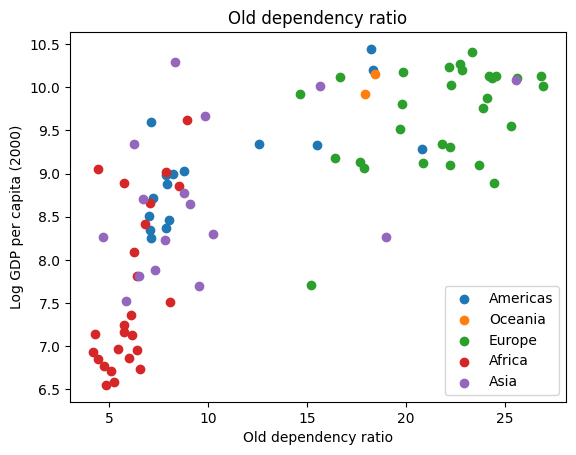

In [55]:
import matplotlib.pyplot as plt

plt.figure()

for c in df_clean["continent"].unique():
    subset = df_clean[df_clean["continent"] == c]
    plt.scatter(subset["old_dependency_ratio"], subset["ln_gdppc2000"], label=c)

plt.xlabel("Old dependency ratio")
plt.ylabel("Log GDP per capita (2000)")
plt.title("Old dependency ratio")
plt.legend()

plt.show()

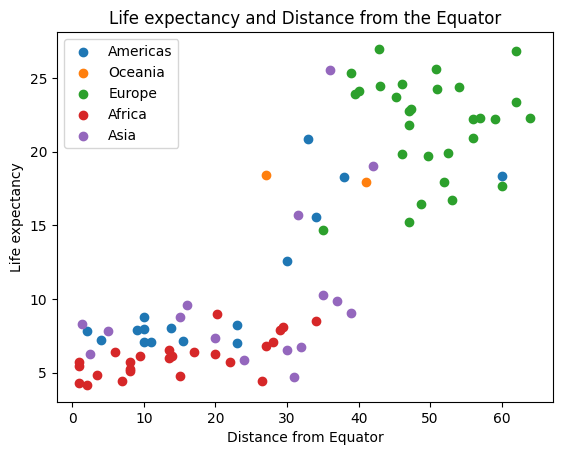

In [56]:
import matplotlib.pyplot as plt

plt.figure()

for c in df_clean["continent"].unique():
    subset = df_clean[df_clean["continent"] == c]
    plt.scatter(subset["abslat"], subset["old_dependency_ratio"], label=c)

plt.xlabel("Distance from Equator")
plt.ylabel("Life expectancy")
plt.title("Life expectancy and Distance from the Equator")
plt.legend()

plt.show()

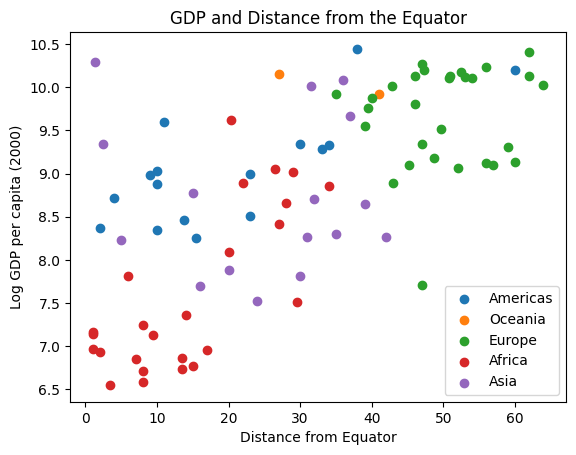

In [57]:
import matplotlib.pyplot as plt

plt.figure()

for c in df_clean["continent"].unique():
    subset = df_clean[df_clean["continent"] == c]
    plt.scatter(subset["abslat"], subset["ln_gdppc2000"], label=c)

plt.xlabel("Distance from Equator")
plt.ylabel("Log GDP per capita (2000)")
plt.title("GDP and Distance from the Equator")
plt.legend()

plt.show()

# Tværsnit

In [58]:
print(df_clean.columns)

Index(['id', 'code', 'country', 'trust', 'articles', 'democ', 'xconst', 'area',
       'abslat', 'temp', 'climate', 'malfal', 'hmicost_hgdp', 'continent',
       'africa', 'europe', 'asia', 'oceania', 'americas', 'cleangdp',
       'cleantrust', 'gdppc2000', 'ln_gdppc2000', 'school', 'life_expectancy',
       'human_capital_index', 'median_age', 'old_dependency_ratio'],
      dtype='str')


In [59]:
import pandas as pd
import statsmodels.api as sm

# Drop missing values (meget vigtigt)
df_tv1 = df_final[['ln_gdppc2000',
             'old_dependency_ratio',
             'human_capital_index',
             'trust',
             'democ',
             'articles']].dropna()

y = df_tv1['ln_gdppc2000']

# Model 1
X1 = sm.add_constant(df_tv1[['old_dependency_ratio']])
model1 = sm.OLS(y, X1).fit()

# Model 2
X2 = sm.add_constant(df_tv1[['old_dependency_ratio',
                              'human_capital_index']])
model2 = sm.OLS(y, X2).fit()

# Model 3
X3 = sm.add_constant(df_tv1[['old_dependency_ratio',
                              'human_capital_index',
                              'trust']])
model3 = sm.OLS(y, X3).fit()

# Model 4
X4 = sm.add_constant(df_tv1[['old_dependency_ratio',
                              'human_capital_index',
                              'trust',
                              'democ']])
model4 = sm.OLS(y, X4).fit()

# Model 5
X5 = sm.add_constant(df_tv1[['old_dependency_ratio',
                              'human_capital_index',
                              'trust',
                              'democ',
                              'articles']])
model5 = sm.OLS(y, X5).fit()

from statsmodels.iolib.summary2 import summary_col

# Saml modeller
results = summary_col(
    [model1, model2, model3, model4, model5],
    stars=True,
    model_names=['(1)', '(2)', '(3)', '(4)', '(5)'],
    info_dict={
        'N': lambda x: f"{int(x.nobs)}",
        'R2': lambda x: f"{x.rsquared:.3f}"
    }
)

print(results)


                        (1)       (2)       (3)       (4)       (5)   
----------------------------------------------------------------------
const                8.0435*** 5.5764*** 5.5976*** 5.9043*** 6.3843***
                     (0.2201)  (0.3537)  (0.3621)  (0.3302)  (0.3420) 
old_dependency_ratio 0.0752*** 0.0097    0.0093    -0.0061   -0.0062  
                     (0.0122)  (0.0120)  (0.0122)  (0.0115)  (0.0106) 
human_capital_index            5.4148*** 5.3216*** 4.5109*** 4.1755***
                               (0.6986)  (0.7578)  (0.7020)  (0.6592) 
trust                                    0.1622    0.1243    -0.9160* 
                                         (0.4872)  (0.4321)  (0.5195) 
democ                                              0.0791*** 0.0483** 
                                                   (0.0198)  (0.0208) 
articles                                                     1.0302***
                                                             (0.3277) 
R-squ

In [60]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

df_tv2 = df_final[['old_dependency_ratio', 'school', 'trust', 'temp']].dropna()

X = df_tv2[['old_dependency_ratio', 'school', 'trust', 'temp']]
X = sm.add_constant(X)

vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif_data)

               Variable        VIF
0                 const  39.703511
1  old_dependency_ratio   2.771007
2                school   3.048818
3                 trust   1.331748
4                  temp   2.503205


In [61]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

df_tv3 = df_final[[
             'old_dependency_ratio',
             'human_capital_index',
             
             'democ',
             'articles']].dropna()

X = df_tv3[[ 'old_dependency_ratio',
             'human_capital_index',
             'democ',
             'articles']]
X = sm.add_constant(X)

vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif_data)

               Variable        VIF
0                 const  29.495595
1  old_dependency_ratio   2.746083
2   human_capital_index   2.626481
3                 democ   2.183177
4              articles   2.087174


In [62]:


df_model = df_final[['ln_gdppc2000',
                     'old_dependency_ratio',
                     'school',
                     'democ',
                     'trust',
                     'abslat']].dropna()

y = df_model['ln_gdppc2000']

# Model 1: Kun aldring
X1 = sm.add_constant(df_model[['old_dependency_ratio']])
model1 = sm.OLS(y, X1).fit(cov_type='HC1')

# Model 2: + human capital (school)
X2 = sm.add_constant(df_model[['old_dependency_ratio', 'school']])
model2 = sm.OLS(y, X2).fit(cov_type='HC1')

# Model 3: + institution (democ)
X3 = sm.add_constant(df_model[['old_dependency_ratio', 'school', 'democ']])
model3 = sm.OLS(y, X3).fit(cov_type='HC1')

# Model 4: + geografi (abslat)
X4 = sm.add_constant(df_model[['old_dependency_ratio', 'school', 'democ', 'abslat']])
model4 = sm.OLS(y, X4).fit(cov_type='HC1')

# Model 5 (robusthed): skift institution til trust
X5 = sm.add_constant(df_model[['old_dependency_ratio', 'school', 'trust', 'abslat']])
model5 = sm.OLS(y, X5).fit(cov_type='HC1')

results = summary_col(
    [model1, model2, model3, model4, model5],
    stars=True,
    model_names=['(1)', '(2)', '(3)', '(4)', '(5)'],
    info_dict={
        'N': lambda x: f"{int(x.nobs)}",
        'R2': lambda x: f"{x.rsquared:.3f}"
    }
)

print(results)


                        (1)       (2)       (3)       (4)       (5)   
----------------------------------------------------------------------
const                7.5233*** 7.2788*** 7.2959*** 7.3149*** 7.2209***
                     (0.2120)  (0.1903)  (0.1914)  (0.2054)  (0.2235) 
old_dependency_ratio 0.1037*** 0.0548*** 0.0430*** 0.0504*** 0.0642***
                     (0.0110)  (0.0161)  (0.0136)  (0.0157)  (0.0175) 
school                         0.1641*** 0.1007**  0.1154**  0.1777***
                               (0.0450)  (0.0475)  (0.0529)  (0.0488) 
democ                                    0.0926*** 0.0907***          
                                         (0.0224)  (0.0233)           
abslat                                             -0.0059   -0.0102  
                                                   (0.0087)  (0.0090) 
trust                                                        0.6721   
                                                             (0.6023) 
R-squ

In [63]:


df_model = df_final[['ln_gdppc2000',
                     'old_dependency_ratio',
                     'school',
                     'democ',
                     'trust',
                     'temp']].dropna()

y = df_model['ln_gdppc2000']

# Model 1: Kun aldring
X1 = sm.add_constant(df_model[['old_dependency_ratio']])
model1 = sm.OLS(y, X1).fit(cov_type='HC1')

# Model 2: + human capital (school)
X2 = sm.add_constant(df_model[['old_dependency_ratio', 'school']])
model2 = sm.OLS(y, X2).fit(cov_type='HC1')

# Model 3: + institution (democ)
X3 = sm.add_constant(df_model[['old_dependency_ratio', 'school', 'democ']])
model3 = sm.OLS(y, X3).fit(cov_type='HC1')

# Model 4: + geografi (abslat)
X4 = sm.add_constant(df_model[['old_dependency_ratio', 'school', 'democ', 'temp']])
model4 = sm.OLS(y, X4).fit(cov_type='HC1')

# Model 5 (robusthed): skift institution til trust
X5 = sm.add_constant(df_model[['old_dependency_ratio', 'school', 'trust', 'temp']])
model5 = sm.OLS(y, X5).fit(cov_type='HC1')

results = summary_col(
    [model1, model2, model3, model4, model5],
    stars=True,
    model_names=['(1)', '(2)', '(3)', '(4)', '(5)'],
    info_dict={
        'N': lambda x: f"{int(x.nobs)}",
        'R2': lambda x: f"{x.rsquared:.3f}"
    }
)

print(results)


                        (1)       (2)       (3)       (4)       (5)   
----------------------------------------------------------------------
const                7.5233*** 7.2788*** 7.2959*** 6.8537*** 6.4564***
                     (0.2120)  (0.1903)  (0.1914)  (0.3983)  (0.4469) 
old_dependency_ratio 0.1037*** 0.0548*** 0.0430*** 0.0487*** 0.0605***
                     (0.0110)  (0.0161)  (0.0136)  (0.0135)  (0.0157) 
school                         0.1641*** 0.1007**  0.1281**  0.1950***
                               (0.0450)  (0.0475)  (0.0572)  (0.0536) 
democ                                    0.0926*** 0.0880***          
                                         (0.0224)  (0.0237)           
temp                                               0.0151    0.0251*  
                                                   (0.0131)  (0.0143) 
trust                                                        0.6606   
                                                             (0.5711) 
R-squ

In [64]:


df_model = df_final[['ln_gdppc2000',
                     'median_age',
                     'school',
                     'democ',
                     'trust',
                     'temp']].dropna()

y = df_model['ln_gdppc2000']

# Model 1: Kun aldring
X1 = sm.add_constant(df_model[['median_age']])
model1 = sm.OLS(y, X1).fit(cov_type='HC1')

# Model 2: + human capital (school)
X2 = sm.add_constant(df_model[['median_age', 'school']])
model2 = sm.OLS(y, X2).fit(cov_type='HC1')

# Model 3: + institution (democ)
X3 = sm.add_constant(df_model[['median_age', 'school', 'democ']])
model3 = sm.OLS(y, X3).fit(cov_type='HC1')

# Model 4: + geografi (abslat)
X4 = sm.add_constant(df_model[['median_age', 'school', 'democ', 'temp']])
model4 = sm.OLS(y, X4).fit(cov_type='HC1')

# Model 5 (robusthed): skift institution til trust
X5 = sm.add_constant(df_model[['median_age', 'school', 'trust', 'temp']])
model5 = sm.OLS(y, X5).fit(cov_type='HC1')

results = summary_col(
    [model1, model2, model3, model4, model5],
    stars=True,
    model_names=['(1)', '(2)', '(3)', '(4)', '(5)'],
    info_dict={
        'N': lambda x: f"{int(x.nobs)}",
        'R2': lambda x: f"{x.rsquared:.3f}"
    }
)

print(results)


                  (1)       (2)       (3)       (4)       (5)   
----------------------------------------------------------------
const          6.0398*** 6.2449*** 6.3499*** 5.7138*** 5.3059***
               (0.2548)  (0.2899)  (0.2657)  (0.5048)  (0.5272) 
median_age     0.1042*** 0.0813*** 0.0730*** 0.0794*** 0.0872***
               (0.0082)  (0.0167)  (0.0145)  (0.0156)  (0.0167) 
school                   0.0776    0.0111    0.0437    0.1124** 
                         (0.0503)  (0.0482)  (0.0498)  (0.0516) 
democ                              0.0918*** 0.0874***          
                                   (0.0233)  (0.0237)           
temp                                         0.0192    0.0272** 
                                             (0.0117)  (0.0130) 
trust                                                  0.5706   
                                                       (0.5461) 
R-squared      0.6906    0.7037    0.7553    0.7642    0.7229   
R-squared Adj. 0.6859   

In [65]:


df_model = df_final[['ln_gdppc2000',
                     'median_age',
                     'school',
                     'democ',
                     'trust',
                     'abslat']].dropna()

y = df_model['ln_gdppc2000']

# Model 1: Kun aldring
X1 = sm.add_constant(df_model[['median_age']])
model1 = sm.OLS(y, X1).fit(cov_type='HC1')

# Model 2: + human capital (school)
X2 = sm.add_constant(df_model[['median_age', 'school']])
model2 = sm.OLS(y, X2).fit(cov_type='HC1')

# Model 3: + institution (democ)
X3 = sm.add_constant(df_model[['median_age', 'school', 'democ']])
model3 = sm.OLS(y, X3).fit(cov_type='HC1')

# Model 4: + geografi (abslat)
X4 = sm.add_constant(df_model[['median_age', 'school', 'democ', 'abslat']])
model4 = sm.OLS(y, X4).fit(cov_type='HC1')

# Model 5 (robusthed): skift institution til trust
X5 = sm.add_constant(df_model[['median_age', 'school', 'trust', 'abslat']])
model5 = sm.OLS(y, X5).fit(cov_type='HC1')

results = summary_col(
    [model1, model2, model3, model4, model5],
    stars=True,
    model_names=['(1)', '(2)', '(3)', '(4)', '(5)'],
    info_dict={
        'N': lambda x: f"{int(x.nobs)}",
        'R2': lambda x: f"{x.rsquared:.3f}"
    }
)

print(results)


                  (1)       (2)       (3)       (4)       (5)   
----------------------------------------------------------------
const          6.0398*** 6.2449*** 6.3499*** 6.2908*** 6.1232***
               (0.2548)  (0.2899)  (0.2657)  (0.2887)  (0.3155) 
median_age     0.1042*** 0.0813*** 0.0730*** 0.0805*** 0.0883***
               (0.0082)  (0.0167)  (0.0145)  (0.0175)  (0.0184) 
school                   0.0776    0.0111    0.0284    0.0929*  
                         (0.0503)  (0.0482)  (0.0469)  (0.0489) 
democ                              0.0918*** 0.0915***          
                                   (0.0233)  (0.0232)           
abslat                                       -0.0075   -0.0097  
                                             (0.0069)  (0.0070) 
trust                                                  0.5621   
                                                       (0.5921) 
R-squared      0.6906    0.7037    0.7553    0.7609    0.7144   
R-squared Adj. 0.6859   

In [66]:


df_model = df_final[['ln_gdppc2000',
                     'old_dependency_ratio',
                     'school',
                     'democ',
                     'trust',
                     'abslat']].dropna()

y = df_model['ln_gdppc2000']

# Model 1: Kun aldring
X1 = sm.add_constant(df_model[['old_dependency_ratio']])
model1 = sm.OLS(y, X1).fit(cov_type='HC1')

# Model 2: + human capital (school)
X2 = sm.add_constant(df_model[['old_dependency_ratio', 'school']])
model2 = sm.OLS(y, X2).fit(cov_type='HC1')

# Model 3: + institution (democ)
X3 = sm.add_constant(df_model[['old_dependency_ratio', 'school', 'democ']])
model3 = sm.OLS(y, X3).fit(cov_type='HC1')

# Model 4: + geografi (abslat)
X4 = sm.add_constant(df_model[['old_dependency_ratio', 'school', 'democ', 'abslat']])
model4 = sm.OLS(y, X4).fit(cov_type='HC1')

# Model 5 (robusthed): skift institution til trust
X5 = sm.add_constant(df_model[['old_dependency_ratio', 'school', 'trust', 'abslat']])
model5 = sm.OLS(y, X5).fit(cov_type='HC1')

results = summary_col(
    [model1, model2, model3, model4, model5],
    stars=True,
    model_names=['(1)', '(2)', '(3)', '(4)', '(5)'],
    info_dict={
        'N': lambda x: f"{int(x.nobs)}",
        'R2': lambda x: f"{x.rsquared:.3f}"
    }
)

print(results)


                        (1)       (2)       (3)       (4)       (5)   
----------------------------------------------------------------------
const                7.5233*** 7.2788*** 7.2959*** 7.3149*** 7.2209***
                     (0.2120)  (0.1903)  (0.1914)  (0.2054)  (0.2235) 
old_dependency_ratio 0.1037*** 0.0548*** 0.0430*** 0.0504*** 0.0642***
                     (0.0110)  (0.0161)  (0.0136)  (0.0157)  (0.0175) 
school                         0.1641*** 0.1007**  0.1154**  0.1777***
                               (0.0450)  (0.0475)  (0.0529)  (0.0488) 
democ                                    0.0926*** 0.0907***          
                                         (0.0224)  (0.0233)           
abslat                                             -0.0059   -0.0102  
                                                   (0.0087)  (0.0090) 
trust                                                        0.6721   
                                                             (0.6023) 
R-squ

In [67]:
df_model = df_final[['ln_gdppc2000',
                     'old_dependency_ratio',
                     'school',
                     'democ',
                     'trust',
                     'abslat']].dropna().copy()

df_model['odr_sq'] = df_model['old_dependency_ratio']**2

y = df_model['ln_gdppc2000']

# Ny model med kvadratisk led
X6 = sm.add_constant(df_model[['old_dependency_ratio', 'odr_sq', 'school', 'democ', 'abslat']])
model6 = sm.OLS(y, X6).fit(cov_type='HC1')

results = summary_col(
    [model1, model2, model3, model4, model5, model6],
    stars=True,
    model_names=['(1)', '(2)', '(3)', '(4)', '(5)', '(6)'],
    info_dict={
        'N': lambda x: f"{int(x.nobs)}",
        'R2': lambda x: f"{x.rsquared:.3f}"
    }
)

print(results)


                        (1)       (2)       (3)       (4)       (5)       (6)   
--------------------------------------------------------------------------------
const                7.5233*** 7.2788*** 7.2959*** 7.3149*** 7.2209*** 6.6538***
                     (0.2120)  (0.1903)  (0.1914)  (0.2054)  (0.2235)  (0.4521) 
old_dependency_ratio 0.1037*** 0.0548*** 0.0430*** 0.0504*** 0.0642*** 0.1999** 
                     (0.0110)  (0.0161)  (0.0136)  (0.0157)  (0.0175)  (0.0825) 
school                         0.1641*** 0.1007**  0.1154**  0.1777*** 0.0609   
                               (0.0450)  (0.0475)  (0.0529)  (0.0488)  (0.0597) 
democ                                    0.0926*** 0.0907***           0.0918***
                                         (0.0224)  (0.0233)            (0.0237) 
abslat                                             -0.0059   -0.0102   -0.0072  
                                                   (0.0087)  (0.0090)  (0.0088) 
trust                      

In [68]:
import statsmodels.api as sm
from statsmodels.iolib.summary2 import summary_col

# Samme sample i alle modeller
df_model = df_final[['ln_gdppc2000',
                     'old_dependency_ratio',
                     'school',
                     'democ',
                     'trust',
                     'abslat']].dropna().copy()

# Lav ODR i anden
df_model['odr_sq'] = df_model['old_dependency_ratio']**2

# Afhængig variabel
y = df_model['ln_gdppc2000']

# Model 1: Kun ODR
X1 = sm.add_constant(df_model[['old_dependency_ratio']])
model1 = sm.OLS(y, X1).fit(cov_type='HC1')

# Model 2: ODR + ODR^2
X2 = sm.add_constant(df_model[['old_dependency_ratio', 'odr_sq']])
model2 = sm.OLS(y, X2).fit(cov_type='HC1')

# Model 3: + school
X3 = sm.add_constant(df_model[['old_dependency_ratio', 'odr_sq', 'school']])
model3 = sm.OLS(y, X3).fit(cov_type='HC1')

# Model 4: + democ
X4 = sm.add_constant(df_model[['old_dependency_ratio', 'odr_sq', 'school', 'democ']])
model4 = sm.OLS(y, X4).fit(cov_type='HC1')

# Model 5: + abslat
X5 = sm.add_constant(df_model[['old_dependency_ratio', 'odr_sq', 'school', 'democ', 'abslat']])
model5 = sm.OLS(y, X5).fit(cov_type='HC1')

# Model 6: robusthed - trust i stedet for democ
X6 = sm.add_constant(df_model[['old_dependency_ratio', 'odr_sq', 'school', 'trust', 'abslat']])
model6 = sm.OLS(y, X6).fit(cov_type='HC1')

# Samlet tabel
results = summary_col(
    [model1, model2, model3, model4, model5, model6],
    stars=True,
    model_names=['(1)', '(2)', '(3)', '(4)', '(5)', '(6)'],
    info_dict={
        'N': lambda x: f"{int(x.nobs)}",
        'R2': lambda x: f"{x.rsquared:.3f}"
    }
)

print(results)


                        (1)       (2)        (3)       (4)       (5)       (6)   
---------------------------------------------------------------------------------
const                7.5233*** 6.2096***  6.7009*** 6.6736*** 6.6538*** 6.5197***
                     (0.2120)  (0.4303)   (0.4798)  (0.4337)  (0.4521)  (0.5240) 
old_dependency_ratio 0.1037*** 0.3336***  0.1834**  0.1814**  0.1999**  0.2201** 
                     (0.0110)  (0.0673)   (0.0897)  (0.0779)  (0.0825)  (0.0963) 
odr_sq                         -0.0076*** -0.0038   -0.0041*  -0.0043*  -0.0045* 
                               (0.0021)   (0.0025)  (0.0022)  (0.0023)  (0.0027) 
school                                    0.1149**  0.0467    0.0609    0.1211*  
                                          (0.0534)  (0.0556)  (0.0597)  (0.0624) 
democ                                               0.0940*** 0.0918***          
                                                    (0.0231)  (0.0237)           
abslat         